In [1]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
import astropy.constants as const

import matplotlib.gridspec as gridspec

import cmocean

import cmcrameri.cm as cmc
#color_map = cmc.vik


In [2]:
def incline(y, z, inc):
    inc_ = np.deg2rad(inc)

    cosi = np.cos(inc_)
    sini = np.sin(inc_)

    y_f =  y*cosi - z*sini
    z_f =  y*sini + z*cosi
    return y_f, z_f
    
def matrix_mine(x, y, z, warp, twist, inc_, PA_):
    #print(warp)
    warp = warp[:, None, None]
    twist = twist[:, None, None]

    cosPA = np.cos(PA_)
    sinPA = np.sin(PA_)
    
    cosi = np.cos(inc_)
    sini = np.sin(inc_)

    '''making sure twist occurs before warp'''

    cosw = np.cos(warp)
    sinw = np.sin(warp)

    cost = np.cos(twist)
    sint = np.sin(twist)
    
    y_w = y*cosw - z*sinw
    z_w = y*sinw + z*cosw
    
    x_t = x*cost - y_w*sint
    y_t = x*sint + y_w*cost

    x_pa = x_t*cosPA - y_t*sinPA
    y_pa = x_t*sinPA + y_t*cosPA

    #self.z_w_max = np.max(z_w)
    #self.x_pa = x_pa
    #self.y_pa = y_pa
    #self.z_w = z_w

    #self.a_w, self.p_w = cart2pol(x_pa, y_pa)
    #self.zf_w = np.linspace(-z_w_max, z_w_max, self.nzc)
    #self.pf_w = np.linspace(-z_w_max, z_w_max, self.nzc)
    
    #y_f =  y_pa*cosi - z_w*sini
    #z_f =  y_pa*sini + z_w*cosi


    return x_pa, y_pa, z_w


def cart2pol(x, y):
    rho = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(rho, phi)

def pol2cart(rho, phi):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    return(x, y)


def w_func(a, r0, dr, r, type):
    #r0 = self.w_r0
    #dr = self.w_dr

    '''same general function for warp & twist, just need to specify which param to use'''
    #if type == "w":
        #a = self.w_i

    #elif type == "pa":
        #a = self.pa
    
    
    r0 = 1.0 if r0 is None else r0
    dr = 1.0 if dr is None else dr
    return np.radians(a / (1.0 + np.exp(-(r0 - r) / (0.1*dr)))) 

def w_func_global(value, glob, r0, dr, r, type):
    #a = value + glob
    #r0 = self.w_r0
    #dr = self.w_dr

    '''same general function for warp & twist, just need to specify which param to use'''
    #if type == "w":
        #a = self.w_i

    #elif type == "pa":
        #a = self.pa
    
    
    r0 = 1.0 if r0 is None else r0
    dr = 1.0 if dr is None else dr

    list = np.radians(glob - value / (1.0 + np.exp(-(r0 - r) / (0.1*dr))))
    #print(list)
    return np.radians(glob - value / (1.0 + np.exp(-(r0 - r) / (0.1*dr)))) 
    a = value + glob
    #r0 = self.w_r0
    #dr = self.w_dr

    '''same general function for warp & twist, just need to specify which param to use'''
    #if type == "w":
        #a = self.w_i

    #elif type == "pa":
        #a = self.pa
    
    
    r0 = 1.0 if r0 is None else r0
    dr = 1.0 if dr is None else dr
    return np.radians(a / (1.0 + np.exp(-(r0 - r) / (0.1*dr)))) 

In [3]:
af = np.linspace(20,300,100)
zf = np.linspace(-30,30,20)
#zf_warp = np.linspace(zmin+1,self.zmax-1,nzc-2)
pf = np.linspace(0,2*np.pi,400)

In [4]:
w_i = 15
w_pa = 0

inc = 80
pa = 180

r0 = 100
dr = 200

In [5]:
warp_i  = w_func(w_i, r0, dr, af, type="w")

twist_i = w_func(w_pa,r0, dr, af, type="pa")

In [6]:
pcf,acf,zcf = np.meshgrid(pf,af,zf)
xi, yi = pol2cart(acf, pcf)

x_w, y_w, z_w = matrix_mine(xi, yi, zcf, warp_i, twist_i, np.deg2rad(inc), np.deg2rad(pa))

r_w, p_w = cart2pol(x_w, y_w)

ty, tz = incline(yi, zcf, inc)

ty_w, tz_w = incline(y_w, z_w, inc)

In [7]:
G = 1.3271244002e11 * u.km**3 / (u.solMass * u.second**2)
star_mass = 2

In [8]:
vel_kep = np.sqrt(G.value*star_mass/(acf*u.au.to(u.km)))*(np.cos(pcf))*np.sin(np.deg2rad(inc))

In [9]:
np.deg2rad(80)

1.3962634015954636

In [10]:
np.sin(np.deg2rad(inc))

0.984807753012208

In [11]:
#np.sin(warp_global_incl[:,None,None])

/tmp/ipykernel_53287/2204463301.py:1: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(xi[:,:,10], ty[:,:,10], vel_kep[:,:,10], vmin=-10, vmax=10)


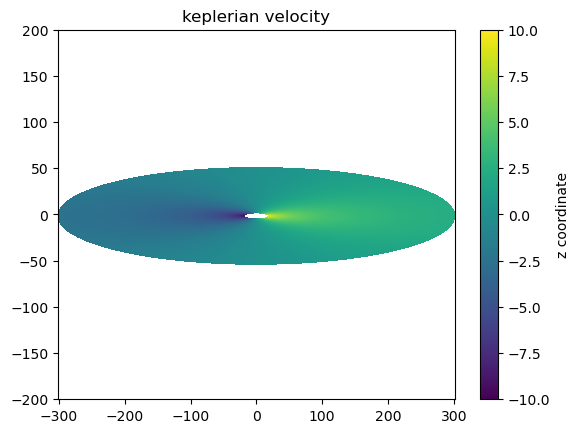

/tmp/ipykernel_53287/2204463301.py:12: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(x_w[:,:,10], ty_w[:,:,10], vel_w[:,:,10], vmin=-10, vmax=10)


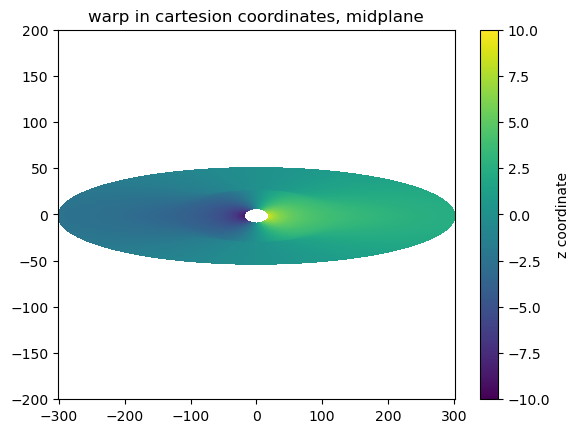

/tmp/ipykernel_53287/2204463301.py:18: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(x_w[:,:,10], ty_w[:,:,10], vel_w[:,:,10] +  vel_kep[:,:,10], cmap=cmocean.cm.balance)


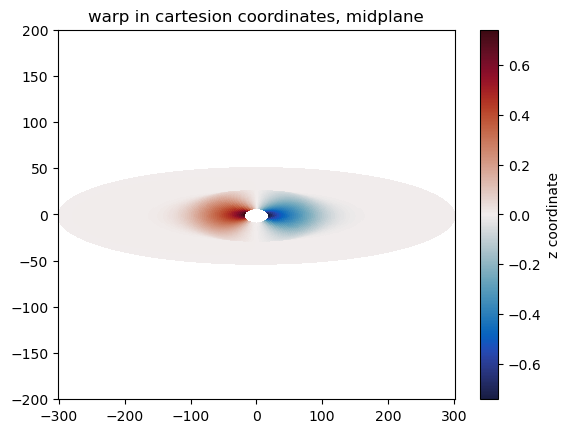

In [12]:
plt.pcolor(xi[:,:,10], ty[:,:,10], vel_kep[:,:,10], vmin=-10, vmax=10)
plt.colorbar(label="z coordinate")
plt.title("keplerian velocity")
plt.ylim(-200,200)
plt.show()

warp_global_incl = w_func_global(w_i, inc, r0, dr, af, type="w")
#vel_w = np.sqrt(G.value*star_mass/(r_w*u.au.to(u.km)))*(np.cos(p_w))*np.sin(warp_global_incl[:,None,None])
vel_kep = np.sqrt(G.value*star_mass/(acf*u.au.to(u.km)))*(np.cos(pcf))*np.sin(np.deg2rad(inc))
vel_w = np.sqrt(G.value*star_mass/(r_w*u.au.to(u.km)))*(np.cos(p_w))*np.sin(warp_global_incl[:,None,None])

plt.pcolor(x_w[:,:,10], ty_w[:,:,10], vel_w[:,:,10], vmin=-10, vmax=10)
plt.colorbar(label="z coordinate")
plt.title("warp in cartesion coordinates, midplane")
plt.ylim(-200,200)
plt.show()

plt.pcolor(x_w[:,:,10], ty_w[:,:,10], vel_w[:,:,10] +  vel_kep[:,:,10], cmap=cmocean.cm.balance)
plt.colorbar(label="z coordinate")
plt.title("warp in cartesion coordinates, midplane")
plt.ylim(-200,200)
plt.show()

In [13]:
warp_global_incl[:,None,None]

array([[[1.13917279]],

       [[1.13987328]],

       [[1.14067547]],

       [[1.1415933 ]],

       [[1.14264242]],

       [[1.14384024]],

       [[1.14520607]],

       [[1.14676116]],

       [[1.14852876]],

       [[1.15053407]],

       [[1.15280413]],

       [[1.15536759]],

       [[1.15825433]],

       [[1.16149499]],

       [[1.16512023]],

       [[1.16915981]],

       [[1.17364146]],

       [[1.17858953]],

       [[1.18402342]],

       [[1.18995588]],

       [[1.19639128]],

       [[1.20332389]],

       [[1.21073643]],

       [[1.21859895]],

       [[1.22686829]],

       [[1.23548824]],

       [[1.24439049]],

       [[1.25349641]],

       [[1.26271963]],

       [[1.27196919]],

       [[1.28115309]],

       [[1.29018191]],

       [[1.29897225]],

       [[1.30744963]],

       [[1.31555075]],

       [[1.32322493]],

       [[1.3304347 ]],

       [[1.33715563]],

       [[1.34337556]],

       [[1.34909328]],

       [[1.35431697]],

       [[1.35906

In [14]:
np.sin(warp_global_incl[:,None,None])

array([[[0.90828775]],

       [[0.90858057]],

       [[0.90891536]],

       [[0.9092977 ]],

       [[0.90973378]],

       [[0.91023046]],

       [[0.9107952 ]],

       [[0.91143613]],

       [[0.91216197]],

       [[0.91298197]],

       [[0.9139058 ]],

       [[0.91494337]],

       [[0.9161046 ]],

       [[0.91739909]],

       [[0.91883579]],

       [[0.92042247]],

       [[0.92216521]],

       [[0.92406781]],

       [[0.92613115]],

       [[0.92835257]],

       [[0.93072537]],

       [[0.93323837]],

       [[0.93587572]],

       [[0.93861697]],

       [[0.94143745]],

       [[0.94430898]],

       [[0.94720089]],

       [[0.95008131]],

       [[0.95291853]],

       [[0.95568244]],

       [[0.95834583]],

       [[0.96088546]],

       [[0.96328275]],

       [[0.9655242 ]],

       [[0.96760132]],

       [[0.96951041]],

       [[0.97125195]],

       [[0.97282995]],

       [[0.97425116]],

       [[0.97552438]],

       [[0.97665971]],

       [[0.97766

In [15]:
vel_kep[:,:,10]

array([[9.27565464, 9.27450458, 9.27105469, ..., 9.27105469, 9.27450458,
        9.27565464],
       [8.68206325, 8.68098679, 8.67775768, ..., 8.67775768, 8.68098679,
        8.68206325],
       [8.18955505, 8.18853966, 8.18549372, ..., 8.18549372, 8.18853966,
        8.18955505],
       ...,
       [2.41786691, 2.41756713, 2.41666785, ..., 2.41666785, 2.41756713,
        2.41786691],
       [2.40633358, 2.40603522, 2.40514024, ..., 2.40514024, 2.40603522,
        2.40633358],
       [2.39496373, 2.39466678, 2.39377603, ..., 2.39377603, 2.39466678,
        2.39496373]])

/tmp/ipykernel_53287/3947582829.py:30: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(x_w[:,:,10], ty_w[:,:,10], vel_resid[:,:,10],  cmap=cmc.vik)
/tmp/ipykernel_53287/3947582829.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


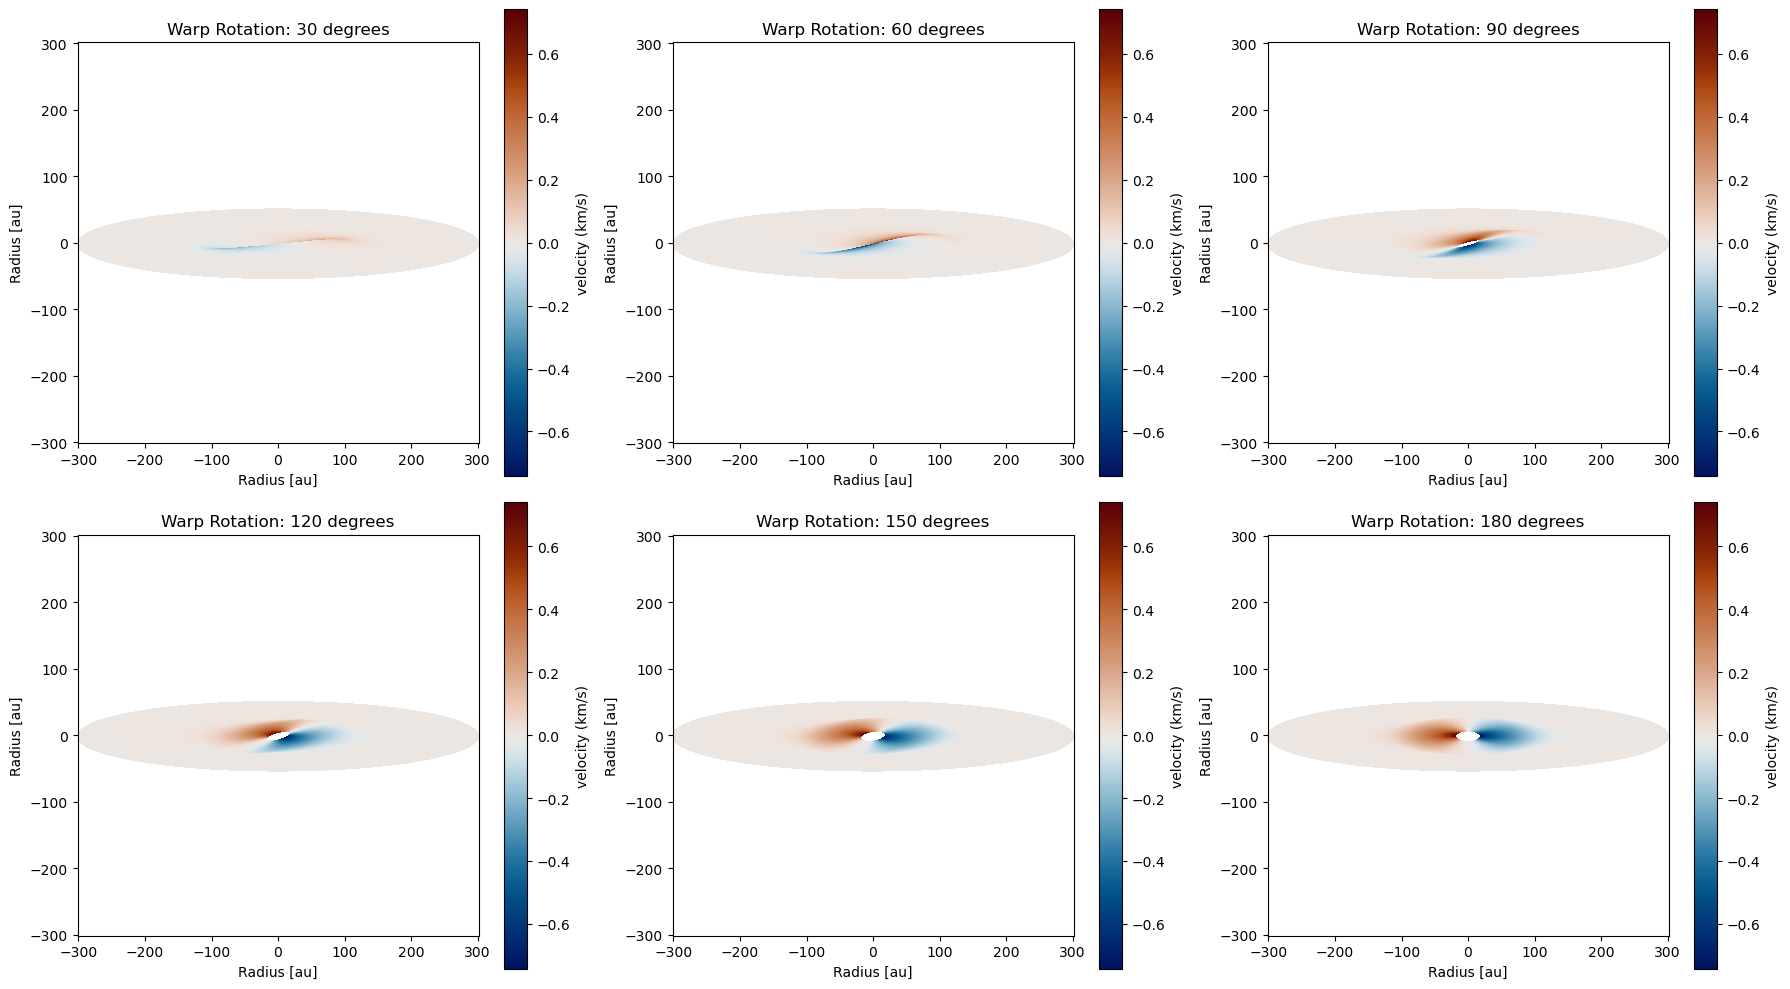

In [16]:


#wi_list = [5, 10, 15]
pa_list = [30, 60, 90, 120, 150, 180]

#ty, tz = incline(yi, zcf, inc)
fig = plt.figure(figsize=(18,10))
gs = gridspec.GridSpec(nrows=2, ncols=3, figure=fig)

#for i in range(len(wi_list)):
for j in range(len(pa_list)):
    warp_i  = w_func(w_i, r0, dr, af, type="w")
    twist_i = w_func(w_pa,r0, dr, af, type="pa")

    x_w, y_w, z_w = matrix_mine(xi, yi, zcf, warp_i, twist_i, np.deg2rad(inc), np.deg2rad(pa_list[j]))
    ty_w, tz_w = incline(y_w, z_w, inc)

    warp_global_incl = w_func_global(w_i, inc, r0, dr, af, type="w")
    vel_w = np.sqrt(G.value*star_mass/(r_w*u.au.to(u.km)))*(np.cos(p_w))*np.sin(warp_global_incl[:,None,None])

    vel_resid = vel_w + vel_kep

    if j < 3:
        ax = fig.add_subplot(gs[0,j])

    else:
        ax = fig.add_subplot(gs[1,j-3])

    ax.set_aspect('equal')
    ax.set_box_aspect(1)

    plt.pcolor(x_w[:,:,10], ty_w[:,:,10], vel_resid[:,:,10],  cmap=cmc.vik)
    plt.colorbar(label="velocity (km/s)")
    plt.title("Warp Rotation: {} degrees".format(pa_list[j]))
    plt.xlabel("Radius [au]")
    plt.ylabel("Radius [au]")
    plt.ylim(-200,200)
    plt.tight_layout()

    plt.savefig("warp_vel_resids.png")
            

/tmp/ipykernel_53287/1065016142.py:35: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(xi[:,:,10], ty[:,:,10], vel_kep[:,:,10], vmin=-9.5, vmax=9.5,   cmap=cmc.vik)
/tmp/ipykernel_53287/1065016142.py:43: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(x_w[:,:,10], ty_w[:,:,10], vel_w[:,:,10], vmin=-9.5, vmax=9.5,  cmap=cmc.vik)


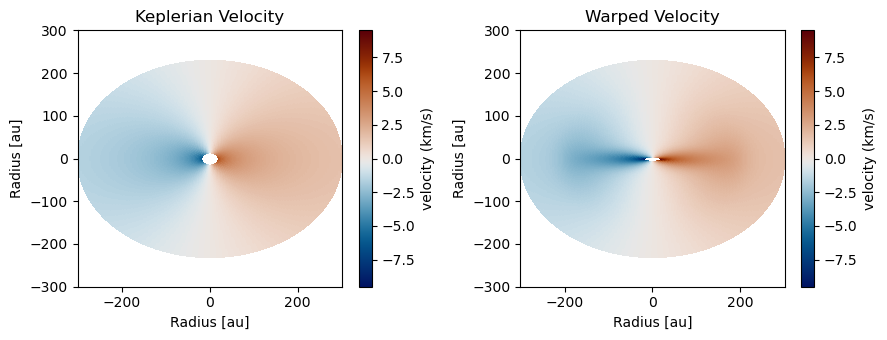

In [35]:
w_i = -35
w_pa = 0

inc = 40
pa = 180

r0 = 200
dr = 150

#wi_list = [5, 10, 15]
pa_list = [30, 60, 90, 120, 150, 180]

#ty, tz = incline(yi, zcf, inc)
fig = plt.figure(figsize=(9,3.5))
#fig = plt.figure()
gs = gridspec.GridSpec(nrows=1, ncols=2, figure=fig)


warp_i  = w_func(w_i, r0, dr, af, type="w")
twist_i = w_func(w_pa,r0, dr, af, type="pa")

ty, tz = incline(yi, zcf, inc)
vel_kep = np.sqrt(G.value*star_mass/(acf*u.au.to(u.km)))*(np.cos(pcf))*np.sin(np.deg2rad(inc))

x_w, y_w, z_w = matrix_mine(xi, yi, zcf, warp_i, twist_i, np.deg2rad(inc), np.deg2rad(pa))
ty_w, tz_w = incline(y_w, z_w, inc)

warp_global_incl = w_func_global(w_i, inc, r0, dr, af, type="w")
vel_w = np.sqrt(G.value*star_mass/(r_w*u.au.to(u.km)))*(np.cos(p_w))*np.sin(warp_global_incl[:,None,None])

ax.set_aspect('equal')
ax.set_box_aspect(1)

ax = fig.add_subplot(gs[0,0])
plt.pcolor(xi[:,:,10], ty[:,:,10], vel_kep[:,:,10], vmin=-9.5, vmax=9.5,   cmap=cmc.vik)
plt.colorbar(label="velocity (km/s)")
plt.title("Keplerian Velocity")
plt.xlabel("Radius [au]")
plt.ylabel("Radius [au]")
plt.ylim(-300,300)

ax = fig.add_subplot(gs[0,1])
plt.pcolor(x_w[:,:,10], ty_w[:,:,10], vel_w[:,:,10], vmin=-9.5, vmax=9.5,  cmap=cmc.vik)
plt.colorbar(label="velocity (km/s)")
plt.title("Warped Velocity")
plt.xlabel("Radius [au]")
plt.ylabel("Radius [au]")
plt.ylim(-300,300)

plt.tight_layout()

plt.savefig("warp_vel_compare.png")
        

In [31]:
np.max(vel_w) - np.max(vel_kep)

0.756888916983101

In [34]:
np.max(vel_w)

10.032543552444045

/tmp/ipykernel_53287/533682864.py:80: RuntimeWarning: overflow encountered in exp
  return np.radians(a / (1.0 + np.exp(-(r0 - r) / (0.1*dr))))
/tmp/ipykernel_53287/533682864.py:98: RuntimeWarning: overflow encountered in exp
  list = np.radians(glob - value / (1.0 + np.exp(-(r0 - r) / (0.1*dr))))
/tmp/ipykernel_53287/533682864.py:100: RuntimeWarning: overflow encountered in exp
  return np.radians(glob - value / (1.0 + np.exp(-(r0 - r) / (0.1*dr))))
/tmp/ipykernel_53287/4145939941.py:36: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(x_w[:,:,10], ty_w[:,:,10], tz_w[:,:,10], cmap=cmocean.cm.thermal, vmin=-300, vmax=300)
/tmp/ipykernel_53287/4145939941.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


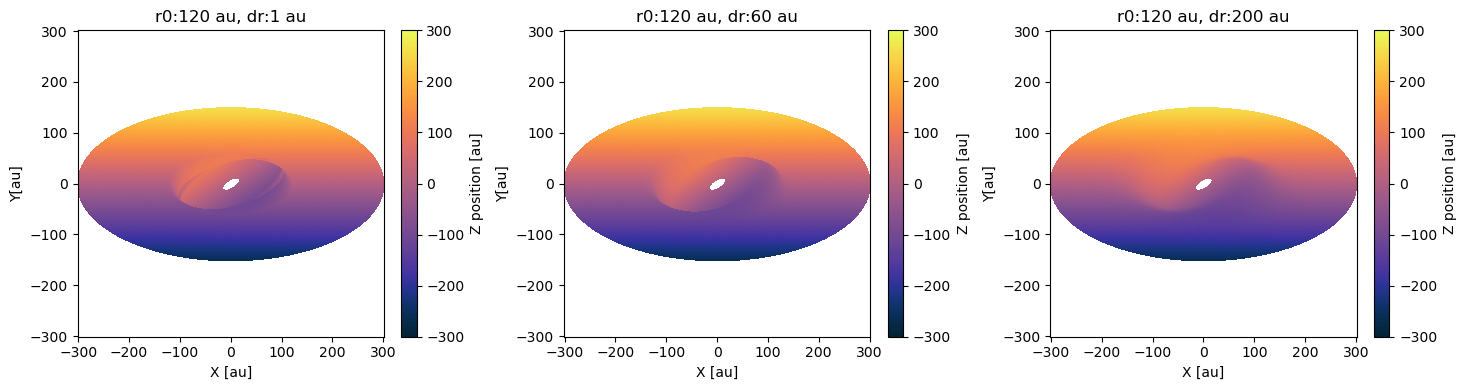

In [20]:
w_i = 28
w_pa = 45

inc = 60
pa = 45

r0 = 200
dr = 150

#wi_list = [5, 10, 15]
r0_list = [120]
dr_list = [1, 60, 200]

#ty, tz = incline(yi, zcf, inc)
fig = plt.figure(figsize=(15,4))
gs = gridspec.GridSpec(nrows=1, ncols=3, figure=fig)

for i in range(len(r0_list)):
    for j in range(len(dr_list)):
        warp_i  = w_func(w_i, r0_list[i], dr_list[j], af, type="w")
        twist_i = w_func(w_pa,r0_list[i], dr_list[j], af, type="pa")

        x_w, y_w, z_w = matrix_mine(xi, yi, zcf, warp_i, twist_i, np.deg2rad(inc), np.deg2rad(pa))
        ty_w, tz_w = incline(y_w, z_w, inc)

        warp_global_incl = w_func_global(w_i, inc, r0_list[i], dr_list[j], af, type="w")
        vel_w = np.sqrt(G.value*star_mass/(r_w*u.au.to(u.km)))*(np.cos(p_w))*np.sin(warp_global_incl[:,None,None])

        vel_resid = vel_w + vel_kep

        ax = fig.add_subplot(gs[i,j])

        ax.set_aspect('equal')
        ax.set_box_aspect(1)

        plt.pcolor(x_w[:,:,10], ty_w[:,:,10], tz_w[:,:,10], cmap=cmocean.cm.thermal, vmin=-300, vmax=300)
        #plt.pcolor(x_w[:,:,10], ty_w[:,:,10], tz_w[:,:,10], cmap=cmocean.cm.matter)
        plt.colorbar(label="Z position [au]",fraction=0.046, pad=0.04)
        plt.title("r0:{} au, dr:{} au".format(r0_list[i], dr_list[j]))
        plt.xlabel("X [au]")
        plt.ylabel("Y[au]")
        plt.ylim(-200,200)
        plt.tight_layout()

        
        #plt.savefig("warp_r0_dr.png")
            

/tmp/ipykernel_53287/722024854.py:36: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(x_w[:,:,10], ty_w[:,:,10], tz_w[:,:,10], cmap=cmocean.cm.thermal, vmin=-300, vmax=300)
/tmp/ipykernel_53287/722024854.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


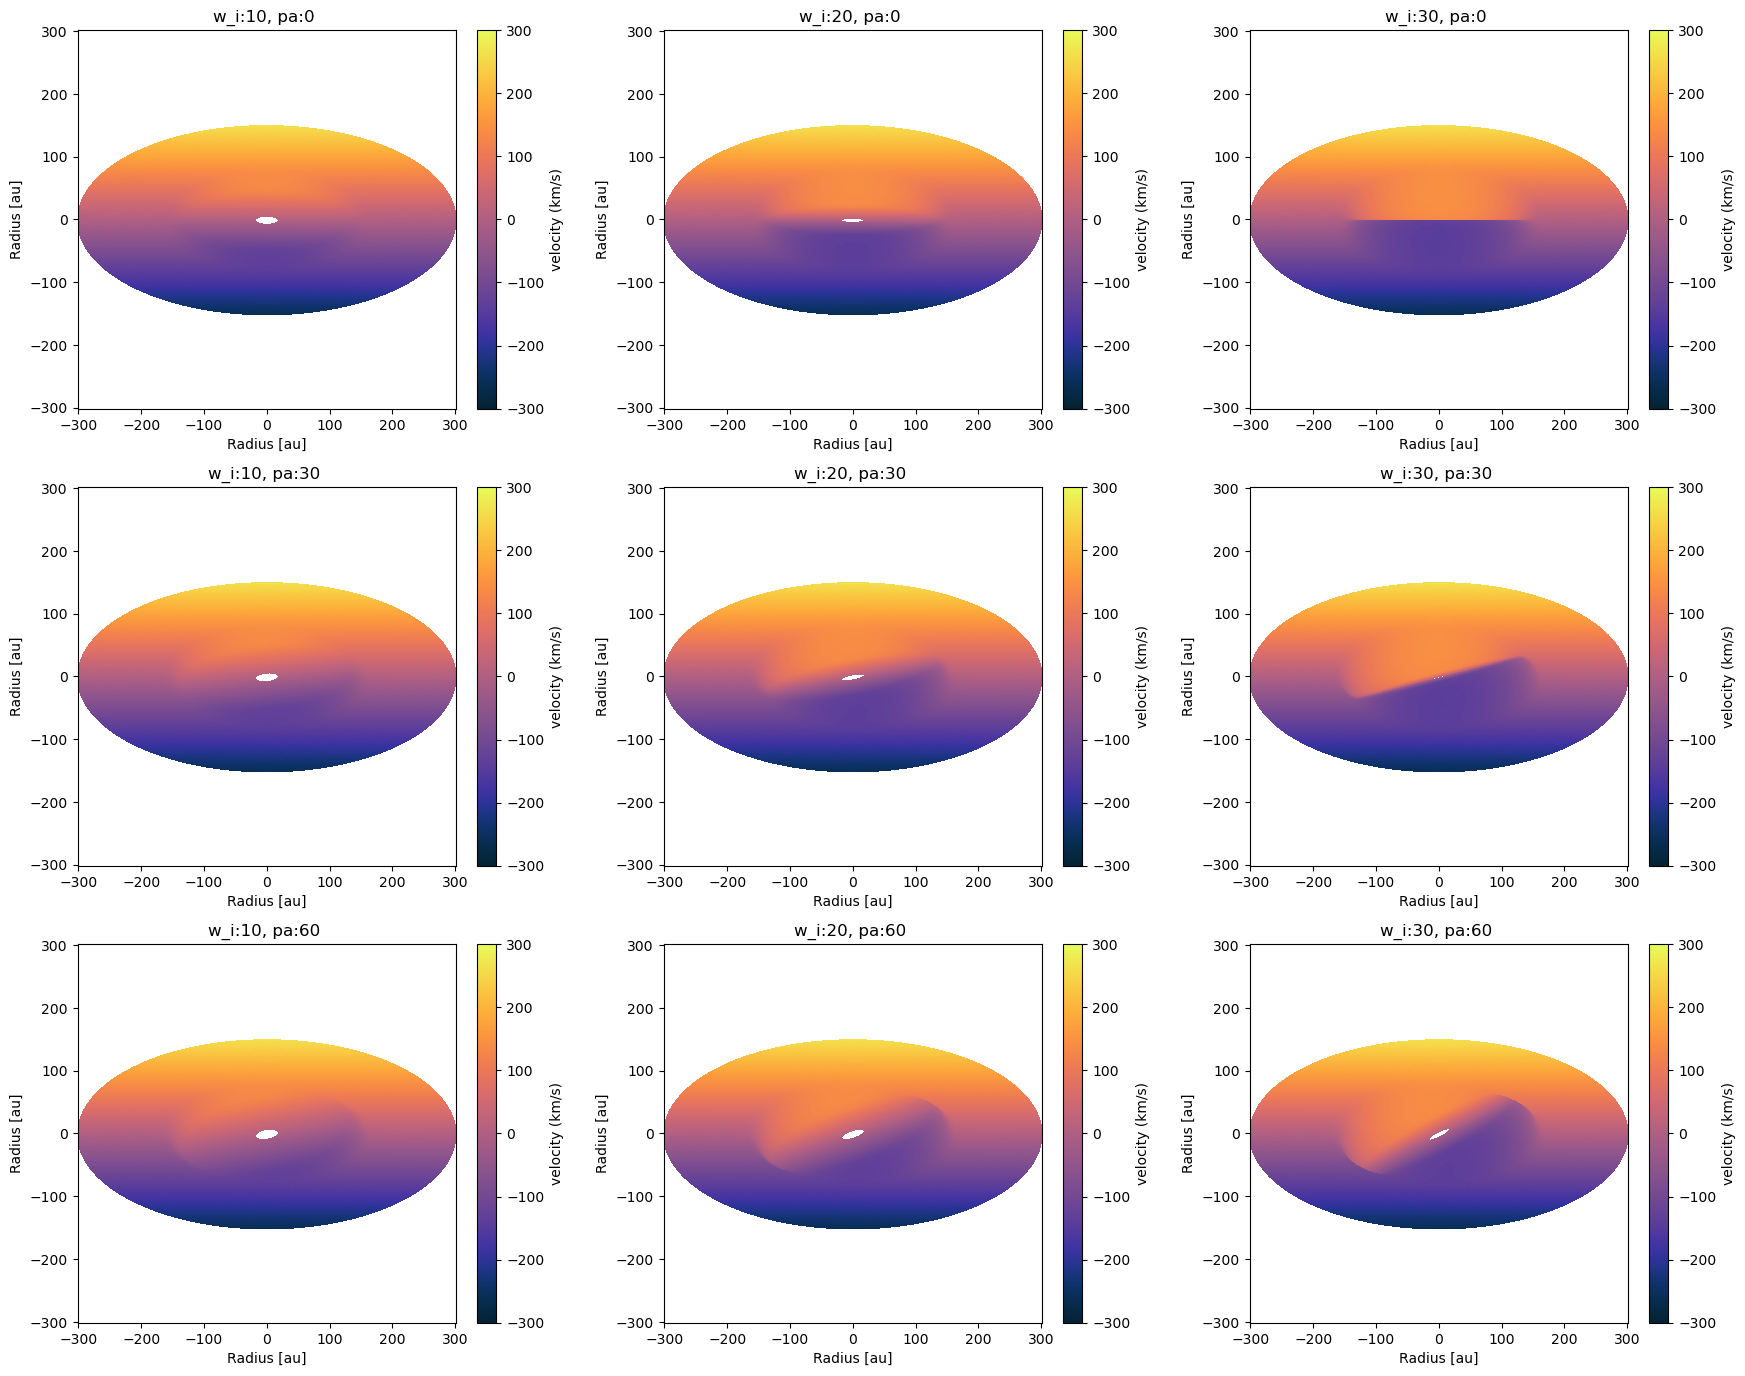

In [21]:
w_i = 25
w_pa = 0

inc = 60
pa = 90

r0 = 150
dr = 50

#wi_list = [5, 10, 15]
wi_list = [10, 20, 30]
pa_list = [0, 30, 60,]

#ty, tz = incline(yi, zcf, inc)
fig = plt.figure(figsize=(18,18))
gs = gridspec.GridSpec(nrows=4, ncols=3, figure=fig)

for i in range(len(wi_list)):
    for j in range(len(pa_list)):
        warp_i  = w_func(wi_list[i], r0, dr, af, type="w")
        twist_i = w_func(w_pa,r0, dr, af, type="pa")

        x_w, y_w, z_w = matrix_mine(xi, yi, zcf, warp_i, twist_i, np.deg2rad(inc), np.deg2rad(pa_list[j]))
        ty_w, tz_w = incline(y_w, z_w, inc)

        #warp_global_incl = w_func_global(w_i, inc, r0, dr, af, type="w")
        #vel_w = np.sqrt(G.value*star_mass/(r_w*u.au.to(u.km)))*(np.cos(p_w))*np.sin(warp_global_incl[:,None,None])

        #vel_resid = vel_w + vel_kep

        ax = fig.add_subplot(gs[j,i])

        ax.set_aspect('equal')
        ax.set_box_aspect(1)

        plt.pcolor(x_w[:,:,10], ty_w[:,:,10], tz_w[:,:,10], cmap=cmocean.cm.thermal, vmin=-300, vmax=300)
        plt.colorbar(label="velocity (km/s)",fraction=0.046, pad=0.04)
        plt.title("w_i:{}, pa:{} ".format(wi_list[i], pa_list[j]))
        plt.xlabel("Radius [au]")
        plt.ylabel("Radius [au]")
        plt.ylim(-200,200)
        plt.tight_layout()

        plt.savefig("warp_i_pa.png")
            

/tmp/ipykernel_53287/180803177.py:35: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(x_w[:,:,10], ty_w[:,:,10], tz_w[:,:,10], cmap=cmocean.cm.thermal,vmin=-300, vmax=300)
/tmp/ipykernel_53287/180803177.py:56: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(x_w[:,:,10], ty_w[:,:,10], tz_w[:,:,10], cmap=cmocean.cm.thermal,vmin=-300, vmax=300)


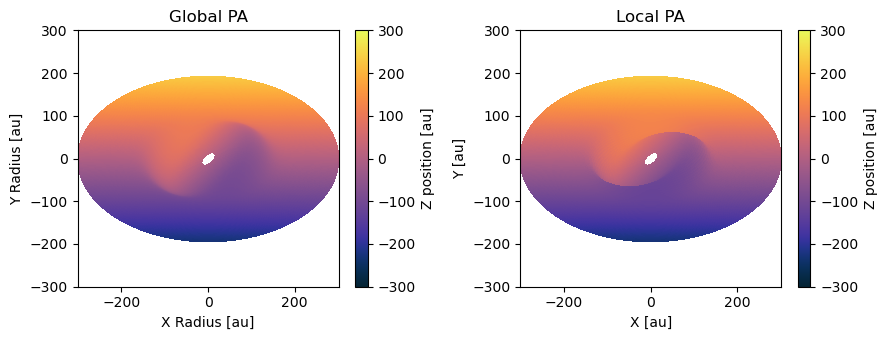

In [22]:
w_i = 35
w_pa = 0

inc = 50
pa = 90

r0 = 130
dr = 115

#wi_list = [5, 10, 15]
pa_list = [30, 60, 90, 120, 150, 180]

#ty, tz = incline(yi, zcf, inc)
fig = plt.figure(figsize=(9,3.5))
#fig = plt.figure()
gs = gridspec.GridSpec(nrows=1, ncols=2, figure=fig)


warp_i  = w_func(w_i, r0, dr, af, type="w")
twist_i = w_func(w_pa,r0, dr, af, type="pa")

#ty, tz = incline(yi, zcf, inc)
#vel_kep = np.sqrt(G.value*star_mass/(acf*u.au.to(u.km)))*(np.cos(pcf))*np.sin(np.deg2rad(inc))

x_w, y_w, z_w = matrix_mine(xi, yi, zcf, warp_i, twist_i, np.deg2rad(inc), np.deg2rad(pa))
ty_w, tz_w = incline(y_w, z_w, inc)

#warp_global_incl = w_func_global(w_i, inc, r0, dr, af, type="w")
#vel_w = np.sqrt(G.value*star_mass/(r_w*u.au.to(u.km)))*(np.cos(p_w))*np.sin(warp_global_incl[:,None,None])

ax.set_aspect('equal')
ax.set_box_aspect(1)

ax = fig.add_subplot(gs[0,0])
plt.pcolor(x_w[:,:,10], ty_w[:,:,10], tz_w[:,:,10], cmap=cmocean.cm.thermal,vmin=-300, vmax=300)
plt.colorbar(label="Z position [au]")
plt.title("Global PA")
plt.xlabel("X Radius [au]")
plt.ylabel("Y Radius [au]")
plt.ylim(-300,300)


w_pa = 90
pa = 0

warp_i  = w_func(w_i, r0, dr, af, type="w")
twist_i = w_func(w_pa,r0, dr, af, type="pa")

#ty, tz = incline(yi, zcf, inc)
#vel_kep = np.sqrt(G.value*star_mass/(acf*u.au.to(u.km)))*(np.cos(pcf))*np.sin(np.deg2rad(inc))

x_w, y_w, z_w = matrix_mine(xi, yi, zcf, warp_i, twist_i, np.deg2rad(inc), np.deg2rad(pa))
ty_w, tz_w = incline(y_w, z_w, inc)

ax = fig.add_subplot(gs[0,1])
plt.pcolor(x_w[:,:,10], ty_w[:,:,10], tz_w[:,:,10], cmap=cmocean.cm.thermal,vmin=-300, vmax=300)
plt.colorbar(label="Z position [au]")
plt.title("Local PA")
plt.xlabel("X [au]")
plt.ylabel("Y [au]")
plt.ylim(-300,300)

plt.tight_layout()

plt.savefig("warp_local_global.png")
        